# ESO survey planning

We will start by doing the likelihood ratio to $V_{gcr}$ selection in a repeatable way, then taking out the MW disk by hand.

In [2]:
from astropy.table import Table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# MW plot
from astropy import units as u
from mw_plot import MWSkyMap

# Skycoord
from astropy.coordinates import SkyCoord
from astropy.coordinates import Galactic
from astropy.coordinates import FK5
from astropy.coordinates import ICRS


/Users/mncavieres/opt/anaconda3/envs/speedytest2/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
# set up the plotting
# set font size
plt.rcParams.update({'font.size': 30})
# set the figure size
plt.rcParams.update({'figure.figsize': (6, 6)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})
# set the font to computer modern
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams.update({'font.serif': 'Computer Modern Roman'})
# plot save directory
plot_dir = '/Users/mncavieres/Documents/2024-2/HVS/Plots/eso_p117/'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)



In [4]:
# Read in the data
data = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/all_candidates_topcat.fits')

In [5]:
# Read in S5 HVS1 data
s5hvs1 = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/S5HVS1.fits')

In [6]:
# Read in the simulated HVS data
#simulated = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/speedystar_catalogs/stock_long_corrected.fits')

In [7]:
# select objects that are outside the plane using l and b
candidates = data[(data['b'] > 20) | (data['b'] < -20)]

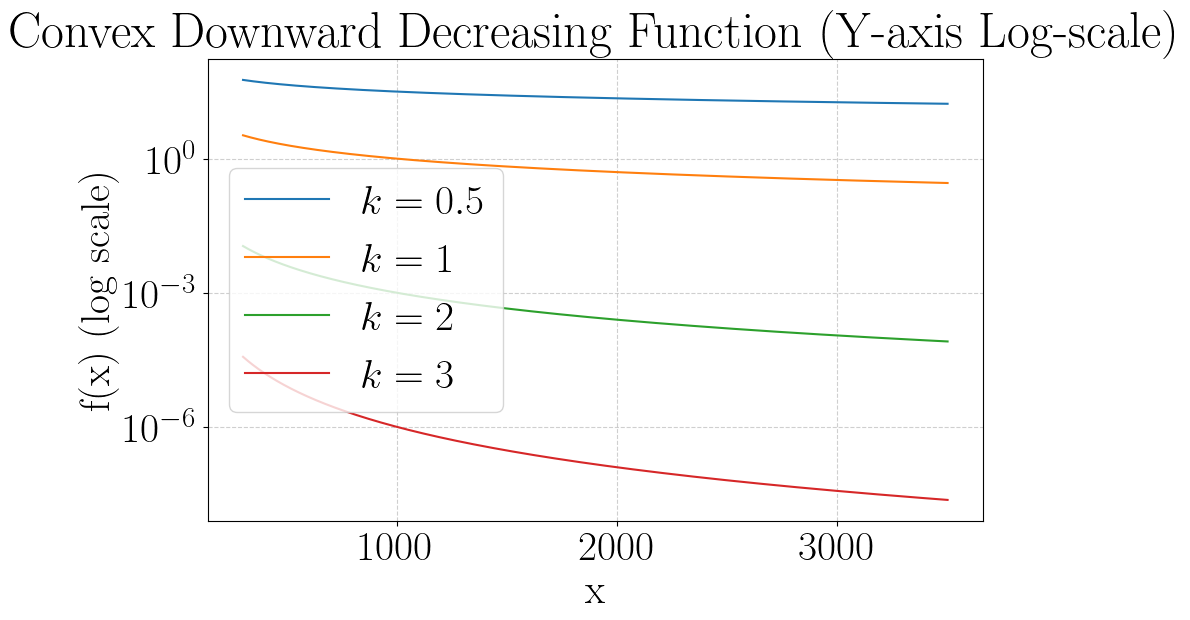

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(300, 3500, 1000)

# Convex downward (concave) decreasing function
def f_convex_down(x, a=1e3, c=0, k=0.5):
    return a / (x + c)**k

# Plot
plt.figure(figsize=(10,6))
k_values = [0.5, 1, 2, 3]
for k in k_values:
    plt.plot(x, f_convex_down(x, k=k), label=f'$k={k}$')
#plt.plot(x, f_convex_down(x), linewidth=2, label=r'$a/(x+c)^k$')

plt.yscale('log')  # Y-axis in log scale
plt.xlabel('x')
plt.ylabel('f(x) (log scale)')
plt.title('Convex Downward Decreasing Function (Y-axis Log-scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()

plt.show()


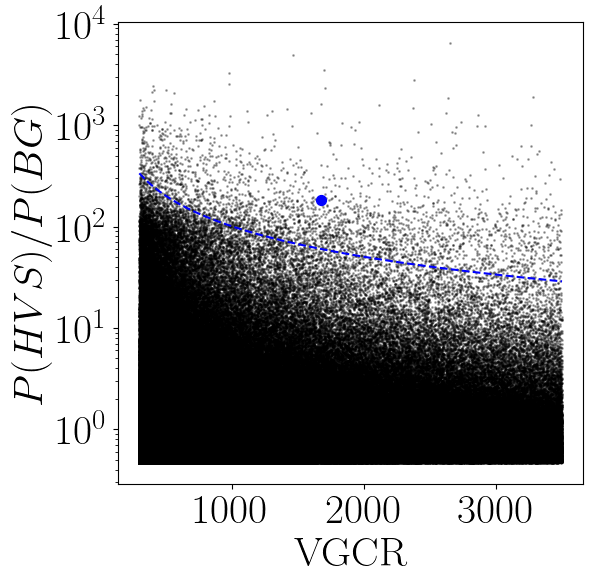

In [9]:
# VGCR vs likelihood ratio
fig, ax = plt.subplots()
ax.scatter(candidates['VGCR'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.3)
# plot the S5HVS1
ax.scatter(s5hvs1['VGCR'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1)

# show limit on likelihood ratio
#ax.axhline(100, color='red', linestyle='--')

# show a linearly decreasing line in logspace
x = np.linspace(300, 3500, 1000)
y =  f_convex_down(x, a=1e5, c=0, k=0.999)# + 200
ax.plot(x, y, color='blue', linestyle='--')

ax.set_yscale('log')
ax.set_xlabel('VGCR')
ax.set_ylabel('$P(HVS)/P(BG)$')
plt.savefig(plot_dir + 'VGCR_vs_likelihood_ratio.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [10]:
# selection of HVS candidates
candidates_HL = candidates[candidates['p_hvs_over_bg'] > f_convex_down(candidates['VGCR'], a=2.6e5, c=0, k=0.999)]
print(len(candidates_HL))

756


316


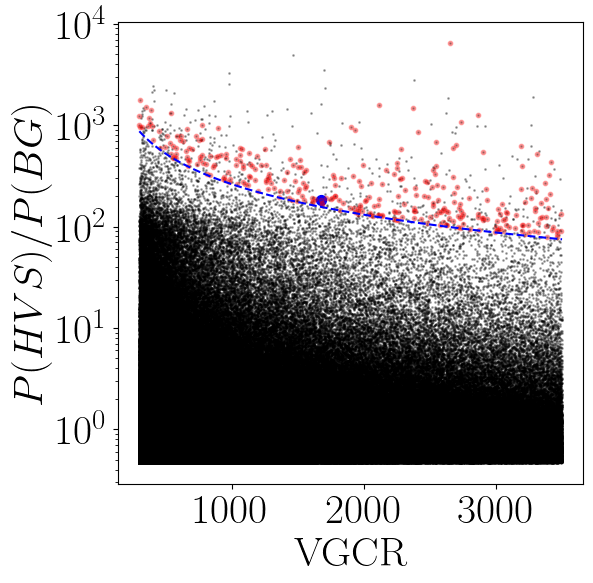

In [11]:
# VGCR vs likelihood ratio
fig, ax = plt.subplots()
ax.scatter(candidates['VGCR'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.3, label='All candidates')

# plot the S5HVS1
ax.scatter(s5hvs1['VGCR'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1, label='S5 HVS1 (Koposov et al. 2020)')

# show limit on likelihood ratio
#ax.axhline(100, color='red', linestyle='--')
threshold_scale_factor = 2.6e5 # 2.6 to include down to S5HVS1

# selection of HVS candidates
candidates_HL = candidates[candidates['p_hvs_over_bg'] > f_convex_down(candidates['VGCR'], a=threshold_scale_factor, c=0, k=0.999)]
# remove the MW disk
candidates_HL = candidates_HL[(candidates_HL['b'] > 30) | (candidates_HL['b'] < -30)]
print(len(candidates_HL))

# selection
ax.scatter(candidates_HL['VGCR'], candidates_HL['p_hvs_over_bg'], c='red', s=10, alpha=0.3)

# show a linearly decreasing line in logspace
x = np.linspace(300, 3500, 1000)
y =  f_convex_down(x, a=threshold_scale_factor, c=0, k=0.999)# + 200
ax.plot(x, y, color='blue', linestyle='--')

ax.set_yscale('log')
ax.set_xlabel('VGCR')
ax.set_ylabel('$P(HVS)/P(BG)$')
plt.savefig(os.path.join(plot_dir, 'VGCR_vs_likelihood_ratio.png'), dpi=600, bbox_inches='tight')
plt.show()

# Color dependant probability limit


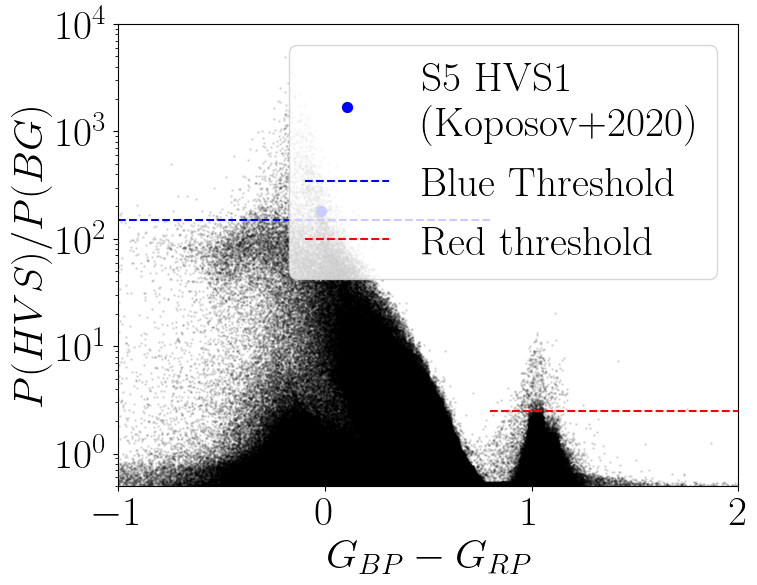

In [12]:
# plot bp_rp vs p_hvs_over_bg
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(candidates['bp_rp_corr'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.1)
# plot the S5HVS1
ax.scatter(s5hvs1['bp_rp_corr'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1, label='S5 HVS1 \n (Koposov+2020)')

# show limit on likelihood ratio
ax.axhline(150, color='blue', linestyle='--', label='Blue Threshold', xmax=0.6)
ax.axhline(2.5, color='red', linestyle='--', xmin= 0.6, xmax=1, label='Red threshold')
ax.set_yscale('log')
ax.set_xlabel('$G_{BP}-G_{RP}$')
ax.set_ylabel('$P(HVS)/P(BG)$')
ax.set_xlim(-1, 2)
ax.set_ylim(0.5, 1e4)
ax.legend(loc='upper right')
plt.savefig(os.path.join(plot_dir, 'bp_rp_vs_likelihood_ratio.png'),
            dpi=600,
            bbox_inches='tight')

plt.show()

In [13]:
# set up the plotting
# set font size
plt.rcParams.update({'font.size': 30})
# set the figure size
plt.rcParams.update({'figure.figsize': (6, 6)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})
# set the font to computer modern
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams.update({'font.serif': 'Computer Modern Roman'})
# plot save directory
plot_dir = '/Users/mncavieres/Documents/2024-2/HVS/Plots/eso_p117/'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)


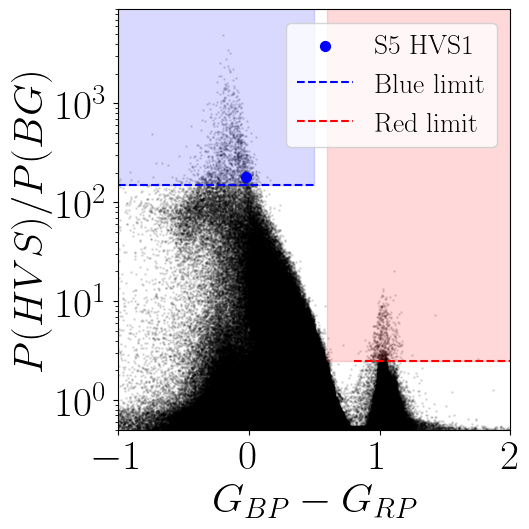

In [14]:
# plot bp_rp vs p_hvs_over_bg
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(candidates['bp_rp_corr'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.1)
# plot the S5HVS1
s5_plot = ax.scatter(s5hvs1['bp_rp_corr'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1, label='S5 HVS1')# \n (Koposov+2020)')

# show limit on likelihood ratio
blue_line = ax.axhline(150, color='blue', linestyle='--', label='Blue limit', xmax=0.5)
red_line = ax.axhline(2.5, color='red', linestyle='--', xmin=0.6, xmax=1, label='Red limit')
ax.set_yscale('log')
ax.set_xlabel('$G_{BP}-G_{RP}$')
ax.set_ylabel('$P(HVS)/P(BG)$')
ax.set_xlim(-1, 2)
ax.set_ylim(0.5, 0.9e4)

# Add shaded regions above thresholds
ax.fill_betweenx([150, 1e4], -1, 0.5, color='blue', alpha=0.15)
ax.fill_betweenx([2.5, 1e4], 0.6, 2, color='red', alpha=0.15)
# legend font
legend_fontsize = 20

# Legend for S5 HVS1 (top right) with smaller font
# legend1 = ax.legend(handles=[s5_plot], loc='upper right', fontsize=legend_fontsize)
# ax.add_artist(legend1)

# # Legend for thresholds (bottom left) with smaller font
# ax.legend(handles=[blue_line, red_line], loc='lower left', fontsize=legend_fontsize)
ax.legend(loc='upper right', fontsize=legend_fontsize)
fig.tight_layout()

plt.savefig(os.path.join(plot_dir, 'bp_rp_vs_likelihood_ratio.png'),
            dpi=600,
            bbox_inches='tight')
plt.show()

# 3 plot for proposal

In [15]:
def var_sel(n_trial, purity, completeness, total_hvs=5):
    """
    Compute the variance of the number of selected objects in a sample of size n_trial
    with a given purity and completeness.
    """
    p_hvs = total_hvs*completeness/114 # expected number of HVS, p_hvs = N_hvs/N_total
    
    return np.sqrt(n_trial * p_hvs * (1 - p_hvs))

def expected_hvs_obs(n_obs, purity, completeness, total_hvs= 41):
    """
    Compute the expected number of HVS in a sample of size n_obs
    with a given purity and completeness.
    """
    p_hvs = total_hvs*completeness/114
    return n_obs * p_hvs





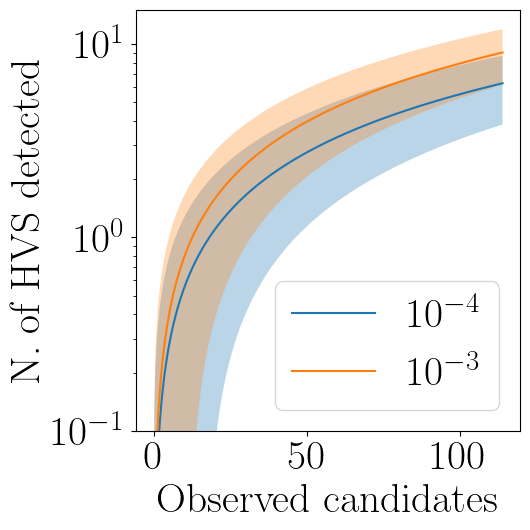

In [16]:
fig, ax = plt.subplots()
x = np.linspace(0, 114, 500)

# for 10^-4
y_2 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=448)
ax.plot(x, y_2, label=r"$10^{-4}$")
y1_2 = y_2 - var_sel(x, 0.976, 0.014, total_hvs=448)
y2_2 = y_2 + var_sel(x, 0.976, 0.014, total_hvs=448)
ax.fill_between(x, y1_2, y2_2, alpha=0.3)

# for 10^-3
y_3 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=646)
ax.plot(x, y_3, label=r"$10^{-3}$")
y1_3 = y_3 - var_sel(x, 0.976, 0.014, total_hvs=646)
y2_3 = y_3 + var_sel(x, 0.976, 0.014, total_hvs=646)
ax.fill_between(x, y1_3, y2_3, alpha=0.3)

ax.set_xlabel("Observed candidates")
ax.set_ylabel("N. of HVS detected")
ax.set_yscale('log')
ax.set_ylim(1e-1, 1.5e1)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'purple.pdf'))
plt.show()


In [17]:
# load XY and likelihood ratio
likelihood_ratio_truncated = np.load('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/cmd_plot/kde_likelihood_ratio.npy')
X_cmd = np.load('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/cmd_plot/kde_X.npy')
Y_cmd = np.load('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/cmd_plot/kde_Y.npy')

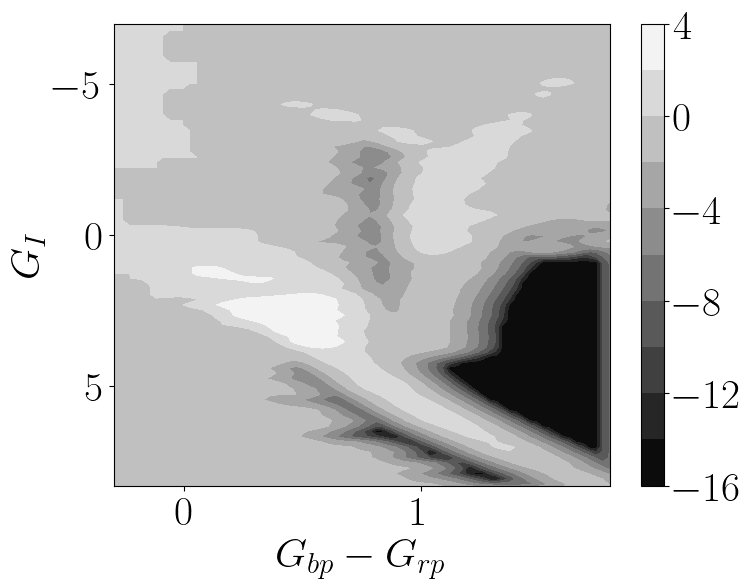

In [18]:

plt.figure(figsize=(8, 6))
plt.contourf(X_cmd, Y_cmd, np.log(likelihood_ratio_truncated.T), cmap='grey', levels = 10)
#plt.contourf(X, Y, posterior_truncated.T, levels=100, cmap='grey')
#plt.colorbar(label='$log(P(HVS) / P(Background))$')}
plt.colorbar()
#plt.scatter(X_data, Y_data, c='red', s=5, alpha=0.5, label='Data Points')
plt.xlabel('$G_{bp} - G_{rp}$')
plt.ylabel('$G_{I}$')
#plt.title('$log(P)$')
plt.xlim(-0.3, 1.8)
plt.ylim(8.3, -7)
#plt.legend()
plt.show()

In [19]:
np.arange(0, 10, 1)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

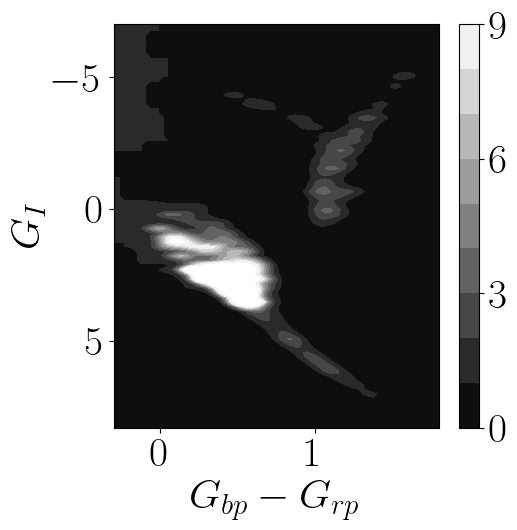

In [20]:

plt.figure(figsize=(6, 6))
plt.contourf(X_cmd, Y_cmd, likelihood_ratio_truncated.T, cmap='grey', levels = np.arange(0, 10, 1))
#plt.contourf(X, Y, posterior_truncated.T, levels=100, cmap='grey')
plt.colorbar( ticks=np.arange(0, 11, 3))#label='$P(HVS) / P(BG)$',
#plt.scatter(X_data, Y_data, c='red', s=5, alpha=0.5, label='Data Points')
plt.xlabel('$G_{bp} - G_{rp}$')
plt.ylabel('$G_{I}$')
#plt.title('$log(P)$')
plt.xlim(-0.3, 1.8)
plt.ylim(8.3, -7)
plt.tight_layout()
plt.savefig('/Users/mncavieres/Documents/2024-2/HVS/Plots/eso_p117/speedystar_CMD_likelihood_ratio.png', dpi=600, bbox_inches='tight')
plt.show()

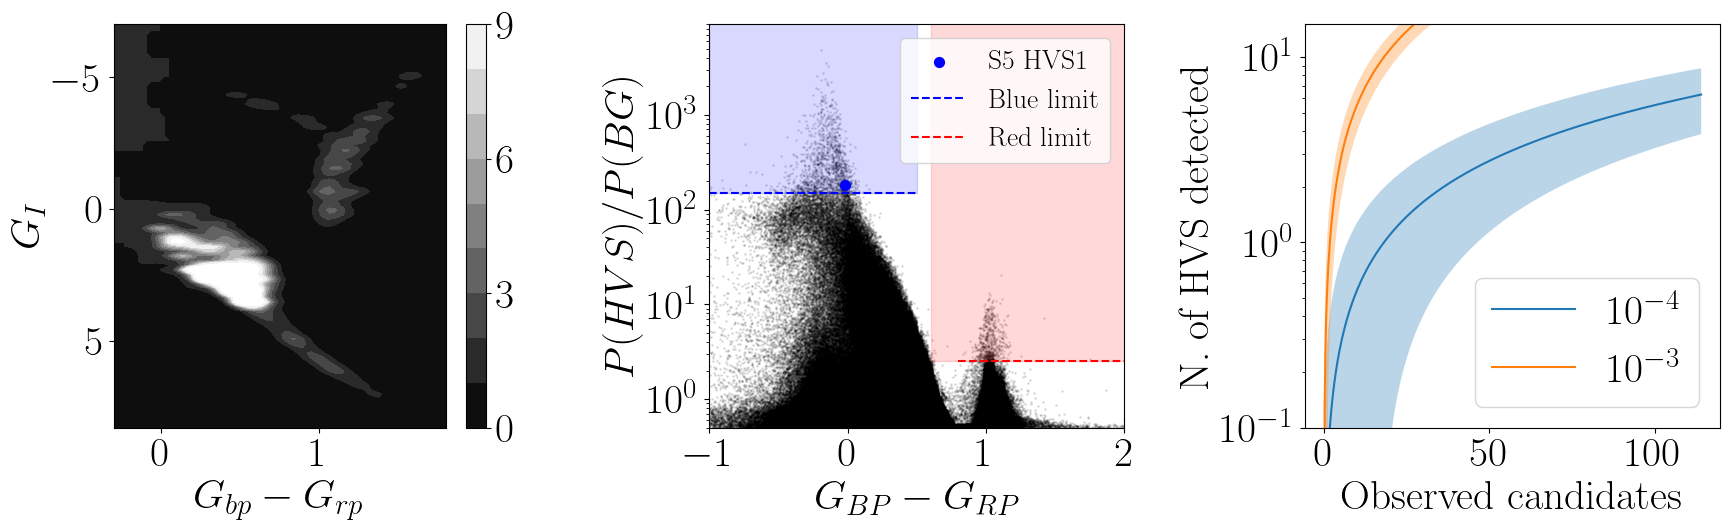

In [21]:
# do the 3 plots in one figure with 3 panels
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# first panel cmd with likelihood ratio

ax[0].contourf(X_cmd, Y_cmd, likelihood_ratio_truncated.T, cmap='grey', levels = np.arange(0, 10, 1))
#plt.contourf(X, Y, posterior_truncated.T, levels=100, cmap='grey')
# add colorbar to the first panel given by the contourf
fig.colorbar(ax[0].collections[0], ax=ax[0], orientation='vertical', ticks=np.arange(0, 11, 3))
#ax[0].colorbar( ticks=np.arange(0, 11, 3))#label='$P(HVS) / P(BG)$',
#plt.scatter(X_data, Y_data, c='red', s=5, alpha=0.5, label='Data Points')
ax[0].set_xlabel('$G_{bp} - G_{rp}$')
ax[0].set_ylabel('$G_{I}$')
#plt.title('$log(P)$')
ax[0].set_xlim(-0.3, 1.8)
ax[0].set_ylim(8.3, -7)

# second panel color vs likelihood ratio
ax[1].scatter(candidates['bp_rp_corr'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.1)
# plot the S5HVS1
s5_plot = ax[1].scatter(s5hvs1['bp_rp_corr'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1, label='S5 HVS1')# \n (Koposov+2020)')

# show limit on likelihood ratio
blue_line = ax[1].axhline(150, color='blue', linestyle='--', label='Blue limit', xmax=0.5)
red_line = ax[1].axhline(2.5, color='red', linestyle='--', xmin=0.6, xmax=1, label='Red limit')
ax[1].set_yscale('log')
ax[1].set_xlabel('$G_{BP}-G_{RP}$')
ax[1].set_ylabel('$P(HVS)/P(BG)$')
ax[1].set_xlim(-1, 2)
ax[1].set_ylim(0.5, 0.9e4)

# Add shaded regions above thresholds
ax[1].fill_betweenx([150, 1e4], -1, 0.5, color='blue', alpha=0.15)
ax[1].fill_betweenx([2.5, 1e4], 0.6, 2, color='red', alpha=0.15)
# legend font
legend_fontsize = 20

# Legend for S5 HVS1 (top right) with smaller font
# legend1 = ax.legend(handles=[s5_plot], loc='upper right', fontsize=legend_fontsize)
# ax.add_artist(legend1)

# # Legend for thresholds (bottom left) with smaller font
# ax.legend(handles=[blue_line, red_line], loc='lower left', fontsize=legend_fontsize)
ax[1].legend(loc='upper right', fontsize=legend_fontsize)

# third panel with the expected number of HVS vs number of observed candidates
# for 10^-4
y_2 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=448)
ax[2].plot(x, y_2, label=r"$10^{-4}$")
y1_2 = y_2 - var_sel(x, 0.976, 0.014, total_hvs=448)
y2_2 = y_2 + var_sel(x, 0.976, 0.014, total_hvs=448)
ax[2].fill_between(x, y1_2, y2_2, alpha=0.3)

# for 10^-3
# y_3 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=646)
# ax[2].plot(x, y_3, label=r"$10^{-3}$")
# y1_3 = y_3 - var_sel(x, 0.976, 0.014, total_hvs=646)
# y2_3 = y_3 + var_sel(x, 0.976, 0.014, total_hvs=646)
# ax[2].fill_between(x, y1_3, y2_3, alpha=0.3)
y_3 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=448*10)
ax[2].plot(x, y_3, label=r"$10^{-3}$")
y1_3 = y_3 - var_sel(x, 0.976, 0.014, total_hvs=448*10)
y2_3 = y_3 + var_sel(x, 0.976, 0.014, total_hvs=448*10)
ax[2].fill_between(x, y1_3, y2_3, alpha=0.3)


ax[2].set_xlabel("Observed candidates")
ax[2].set_ylabel("N. of HVS detected")
ax[2].set_yscale('log')
ax[2].set_ylim(1e-1, 1.5e1)
ax[2].legend()
fig.tight_layout()
# fig.savefig(os.path.join(plot_dir, 'purple.pdf'))
# plt.show()
plt.show()

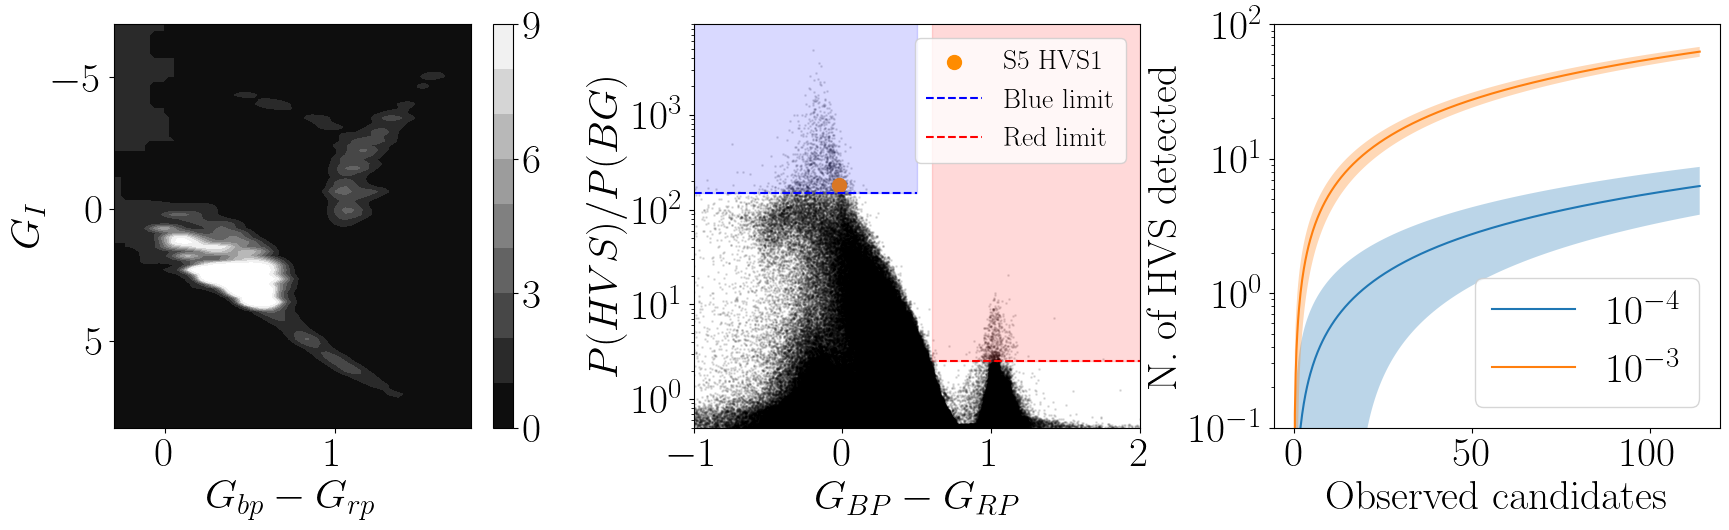

In [28]:
# do the 3 plots in one figure with 3 panels
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# first panel cmd with likelihood ratio

ax[0].contourf(X_cmd, Y_cmd, likelihood_ratio_truncated.T, cmap='grey', levels = np.arange(0, 10, 1))
#plt.contourf(X, Y, posterior_truncated.T, levels=100, cmap='grey')
# add colorbar to the first panel given by the contourf
fig.colorbar(ax[0].collections[0], ax=ax[0], orientation='vertical', ticks=np.arange(0, 11, 3))
#ax[0].colorbar( ticks=np.arange(0, 11, 3))#label='$P(HVS) / P(BG)$',
#plt.scatter(X_data, Y_data, c='red', s=5, alpha=0.5, label='Data Points')
ax[0].set_xlabel('$G_{bp} - G_{rp}$')
ax[0].set_ylabel('$G_{I}$')
#plt.title('$log(P)$')
ax[0].set_xlim(-0.3, 1.8)
ax[0].set_ylim(8.3, -7)

# second panel color vs likelihood ratio
ax[1].scatter(candidates['bp_rp_corr'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.1)
# plot the S5HVS1
s5_plot = ax[1].scatter(s5hvs1['bp_rp_corr'], s5hvs1['p_hvs_over_bg'], c='darkorange', s=100, alpha=1, label='S5 HVS1')# \n (Koposov+2020)')

# show limit on likelihood ratio
blue_line = ax[1].axhline(150, color='blue', linestyle='--', label='Blue limit', xmax=0.5)
red_line = ax[1].axhline(2.5, color='red', linestyle='--', xmin=0.55, xmax=1, label='Red limit')
ax[1].set_yscale('log')
ax[1].set_xlabel('$G_{BP}-G_{RP}$')
ax[1].set_ylabel('$P(HVS)/P(BG)$')
ax[1].set_xlim(-1, 2)
ax[1].set_ylim(0.5, 0.9e4)

# Add shaded regions above thresholds
ax[1].fill_betweenx([150, 1e4], -1, 0.5, color='blue', alpha=0.15)
ax[1].fill_betweenx([2.5, 1e4], 0.6, 2, color='red', alpha=0.15)
# legend font
legend_fontsize = 20

# Legend for S5 HVS1 (top right) with smaller font
# legend1 = ax.legend(handles=[s5_plot], loc='upper right', fontsize=legend_fontsize)
# ax.add_artist(legend1)
# ... rest of your plotting code ...


# # Legend for thresholds (bottom left) with smaller font
# ax.legend(handles=[blue_line, red_line], loc='lower left', fontsize=legend_fontsize)
ax[1].legend(loc='upper right', fontsize=legend_fontsize)

# third panel with the expected number of HVS vs number of observed candidates
# for 10^-4
y_2 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=448)
ax[2].plot(x, y_2, label=r"$10^{-4}$")
y1_2 = y_2 - var_sel(x, 0.976, 0.014, total_hvs=448)
y2_2 = y_2 + var_sel(x, 0.976, 0.014, total_hvs=448)
ax[2].fill_between(x, y1_2, y2_2, alpha=0.3)

# for 10^-3
y_3 = expected_hvs_obs(x, 0.976, 0.014, total_hvs=448*10)
ax[2].plot(x, y_3, label=r"$10^{-3}$")
y1_3 = y_3 - var_sel(x, 0.976, 0.014, total_hvs=448*10)
y2_3 = y_3 + var_sel(x, 0.976, 0.014, total_hvs=448*10)
ax[2].fill_between(x, y1_3, y2_3, alpha=0.3)

ax[2].set_xlabel("Observed candidates")
ax[2].set_ylabel("N. of HVS detected")
ax[2].set_yscale('log')
ax[2].set_ylim(1e-1, 1e2)
ax[2].legend()
fig.tight_layout()

fig.subplots_adjust(wspace=0.3)  # Reduce horizontal space between panels

fig.savefig(os.path.join(plot_dir, 'triple_plot.png'), dpi=600, bbox_inches='tight')
# plt.show()
plt.show()

In [27]:
plot_dir

'/Users/mncavieres/Documents/2024-2/HVS/Plots/eso_p117/'

## Split stars between blue and red

# Remove sources close to the clouds and the disk

In [12]:
# split the candidates in blue and red
candidates_blue = candidates[candidates['bp_rp_corr'] < 0.5] 
candidates_red = candidates[candidates['bp_rp_corr'] > 0.7]

# remove the MW disk
candidates_blue = candidates_blue[(candidates_blue['b'] > 30) | (candidates_blue['b'] < -30)]
candidates_red = candidates_red[(candidates_red['b'] > 30) | (candidates_red['b'] < -30)]

# remove sources close to the LMC and SMC
lmc_skycoord = SkyCoord(ra=80.89416667*u.deg, dec=-69.75611111*u.deg, frame='icrs')
smc_skycoord = SkyCoord(ra=13.18666667*u.deg, dec=-72.82861111*u.deg, frame='icrs')

# define 
candidates_blue_skycoord = SkyCoord(ra=candidates_blue['ra']*u.deg, dec=candidates_blue['dec']*u.deg, frame='icrs')
candidates_red_skycoord = SkyCoord(ra=candidates_red['ra']*u.deg, dec=candidates_red['dec']*u.deg, frame='icrs')

# compute the angular separation
sep_lmc_blue = candidates_blue_skycoord.separation(lmc_skycoord)
sep_smc_blue = candidates_blue_skycoord.separation(smc_skycoord)
sep_lmc_red = candidates_red_skycoord.separation(lmc_skycoord)
sep_smc_red = candidates_red_skycoord.separation(smc_skycoord)

# remove sources close to the LMC and SMC
candidates_blue = candidates_blue[(sep_lmc_blue > 10*u.deg) & (sep_smc_blue > 5*u.deg)]
candidates_red = candidates_red[(sep_lmc_red > 10*u.deg) & (sep_smc_red > 5*u.deg)]

# select the high likelihood candidates
candidates_HL_blue = candidates_blue[candidates_blue['p_hvs_over_bg'] > 150]
candidates_HL_red = candidates_red[candidates_red['p_hvs_over_bg'] > 2.5]

# select those that are observable from the south
candidates_HL_blue = candidates_HL_blue[candidates_HL_blue['dec'] < 0]
candidates_HL_red = candidates_HL_red[candidates_HL_red['dec'] < 0]

print(len(candidates_HL_blue))
print(len(candidates_HL_red))

# save the candidates
candidates_HL_blue.write('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/candidates_HL_blue.fits', overwrite=True)
candidates_HL_red.write('/Users/mncavieres/Documents/2024-2/HVS/Data/p117/candidates_HL_red.fits', overwrite=True)


424
76


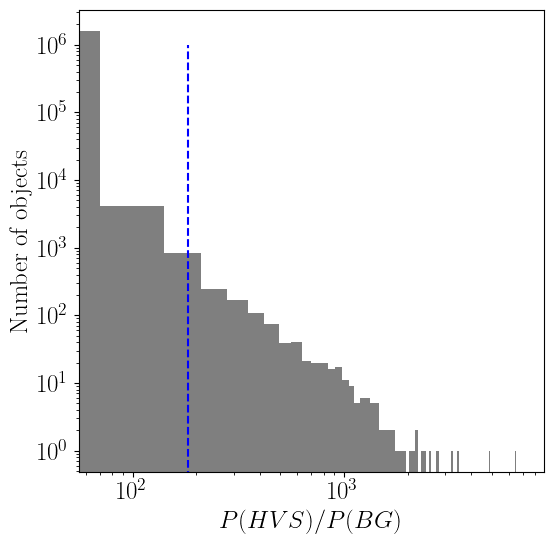

In [57]:
# histogram of p_hvs_over_bg
fig, ax = plt.subplots()
ax.hist(candidates['p_hvs_over_bg'][candidates['p_hvs_over_bg']<1e9], bins=100, color='black', alpha=0.5, range=(0, 7000), log=True)
ax.vlines(s5hvs1['p_hvs_over_bg'], 0, 1e6, color='blue', linestyle='--')
#ax.hist(candidates_HL['p_hvs_over_bg'], bins=100, color='red', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('$P(HVS)/P(BG)$')
ax.set_ylabel('Number of objects')
plt.show()

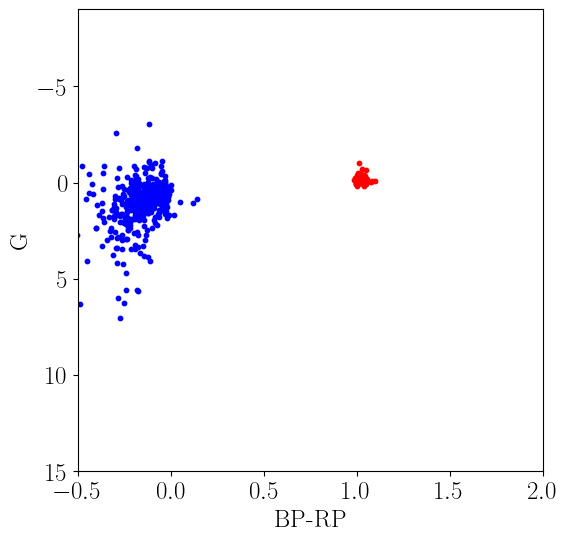

In [58]:
from matplotlib.colors import LogNorm

# selection of HVS candidates
#candidates_HL = candidates[candidates['p_hvs_over_bg'] > f_convex_down(candidates['VGCR'], a=threshold_scale_factor, c=0, k=0.999)]
#candidates_HL = candidates[candidates['p_hvs_over_bg'] > 130]
# remove the MW disk
#candidates_HL = candidates_HL[(candidates_HL['b'] > 20) | (candidates_HL['b'] < -20)]
#print(len(candidates_HL))

# plot CMD
fig, ax = plt.subplots()
#bg_s = ax.scatter(candidates['bp_rp_corr'], candidates['implied_M_g_corr'], c=candidates['p_hvs_over_bg'], s=1, alpha=0.3, cmap='viridis', norm=LogNorm(vmin=1, vmax=1000))
ax.scatter(candidates_HL_blue['bp_rp_corr'], candidates_HL_blue['implied_M_g_corr'], c='blue', s=10, alpha=1)
ax.scatter(candidates_HL_red['bp_rp_corr'], candidates_HL_red['implied_M_g_corr'], c='red', s=10, alpha=1)

plt.gca().invert_yaxis()
ax.set_xlabel('BP-RP')
ax.set_ylabel('G')
ax.set_xlim(-0.5, 2)
ax.set_ylim(15, -9)
#plt.colorbar(bg_s, label='$P(HVS)/P(BG)$')
plt.show()

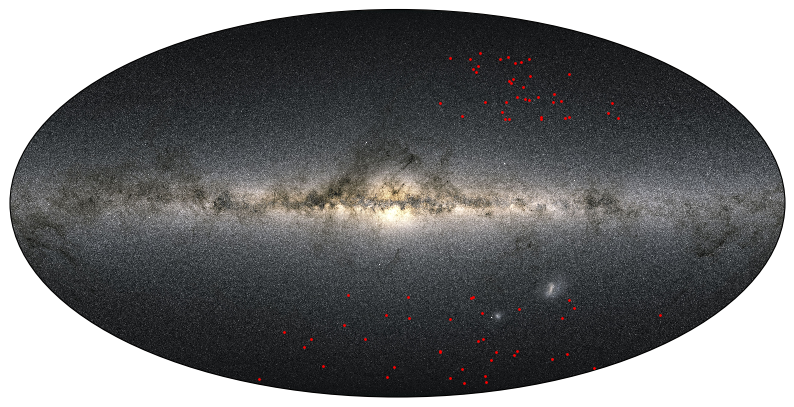

In [ ]:
# mollwide plot
#fig, ax = plt.subplots(figsize=(10, 7))
m = MWSkyMap(projection='mollweide', figsize=(10, 7))
#m.scatter(candidates_HL_blue['ra']*u.deg, candidates_HL_blue['dec']*u.deg, s=1, c='blue', alpha=1)
m.scatter(candidates_HL_red['ra']*u.deg, candidates_HL_red['dec']*u.deg, s=1, c='red', alpha=1)
#m.scatter(s5hvs1['l'], s5hvs1['b'], s=50, c='blue', alpha=1)
plt.savefig(os.path.join(plot_dir,'HVS_candidates_mollwide_red.png'), dpi=300)
plt.show()


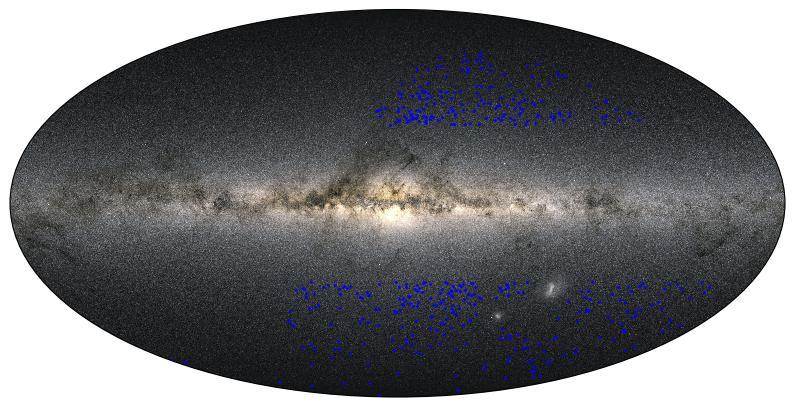

In [263]:
# mollwide plot
#fig, ax = plt.subplots(figsize=(10, 7))
m = MWSkyMap(projection='mollweide', figsize=(10, 7))
m.scatter(candidates_HL_blue['ra']*u.deg, candidates_HL_blue['dec']*u.deg, s=1, c='blue', alpha=1)
#m.scatter(candidates_HL_red['ra']*u.deg, candidates_HL_red['dec']*u.deg, s=1, c='red', alpha=1)
#m.scatter(s5hvs1['l'], s5hvs1['b'], s=50, c='blue', alpha=1)
plt.savefig(os.path.join('HVS_candidates_mollwide_blue.png'), dpi=300)
plt.show()


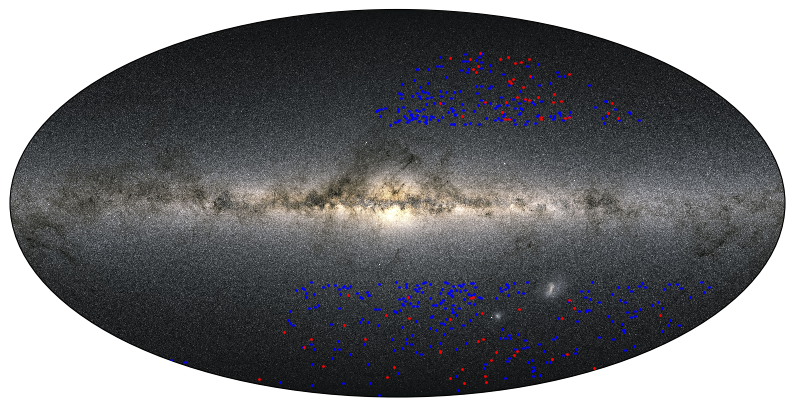

In [16]:

m = MWSkyMap(projection='mollweide', figsize=(10, 7))
m.scatter(candidates_HL_blue['ra']*u.deg, candidates_HL_blue['dec']*u.deg, s=1, c='blue', alpha=1)
m.scatter(candidates_HL_red['ra']*u.deg, candidates_HL_red['dec']*u.deg, s=1, c='red', alpha=1)
#m.scatter(s5hvs1['ra']*u.deg, s5hvs1['dec']*u.deg, s=50, c='yellow', alpha=1, label='S5-HVS1')
#plt.legend()
plt.savefig(os.path.join('HVS_candidates_mollwide_both.png'), dpi=300)
plt.show()


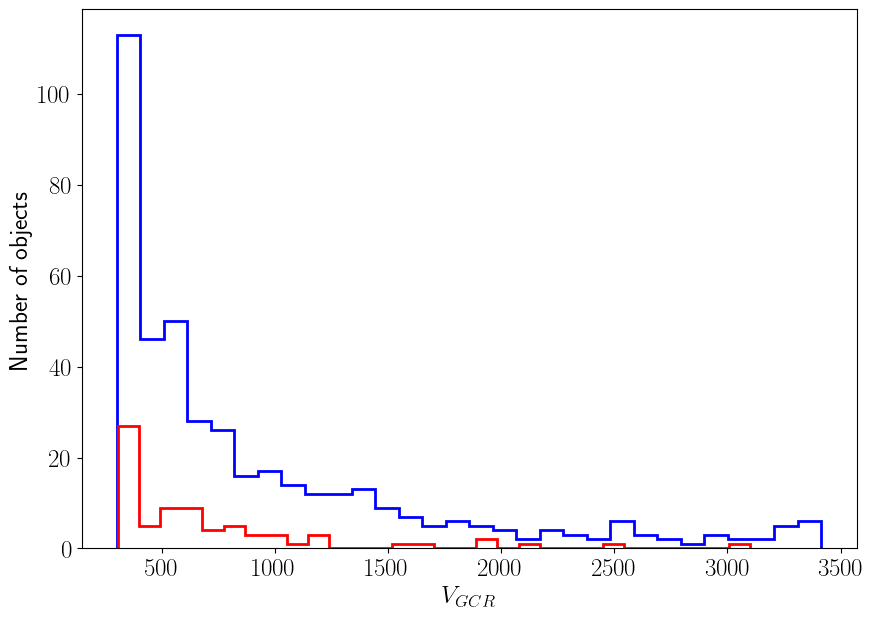

In [257]:
# VGCR histogram

fig, ax = plt.subplots()
ax.hist(candidates_HL_blue['VGCR'], bins=30, color='blue', histtype='step', linewidth=2)
#ax.hist(s5hvs1['VGCR'], bins=100, color='blue', histtype='step', linewidth=2)
ax.hist(candidates_HL_red['VGCR'], bins=30, color='red', histtype='step', linewidth=2)
ax.set_xlabel('$V_{GCR}$')
ax.set_ylabel('Number of objects')
plt.show()

In [59]:
print(len(candidates_HL_blue))
print(len(candidates_HL_red))

424
76


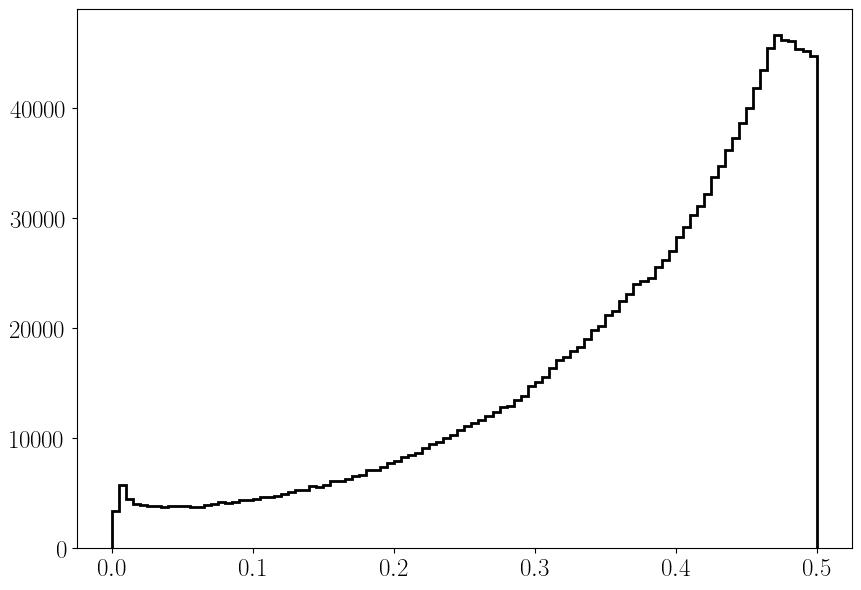

In [149]:
# VGCR histogram

fig, ax = plt.subplots()
ax.hist(candidates['p_background'], bins=100, color='black', histtype='step', linewidth=2)
#ax.hist(s5hvs1['VGCR'], bins=100, color='blue', histtype='step', linewidth=2)
plt.show()

# Clean it further

In [20]:
# save the candidates
candidates_HL_blue.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_blue.fits', overwrite=True)
candidates_HL_red.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_red.fits', overwrite=True)

In [38]:
print(len(candidates_HL_blue)+ len(candidates_HL_red))

500


## Are they in Gaia RVs?

In [21]:
# load catalog with Gaia rv
gaia_rv = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_purplexgaiarv.fits')

In [ ]:
# see how many sources have rv
print(len(gaia_rv[~np.isnan(gaia_rv['RV'])]))
# remove those from the catalog
candidates_purple = gaia_rv[np.isnan(gaia_rv['RV'])]

# now the catalog is cleared of stars with Gaia RVs

## Are they in LAMOST

In [29]:
# load LAMOST DR9 low resolution catalog
lamost_lr = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/LAMOST/dr9_v2.0_LRS_stellar.fits')
lamost_mr = Table.read('/Users/mncavieres/Documents/2024-2/HVS/Data/LAMOST/dr9_v2.0_MRS_stellar.fits')

In [35]:
# crossmatch catalog with LAMOST
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import match_coordinates_sky

# define the skycoord for the candidates
candidates_skycoord = SkyCoord(ra=candidates_purple['ra']*u.deg, dec=candidates_purple['dec']*u.deg)
lamost_lr_skycoord = SkyCoord(ra=lamost_lr['ra'], dec=lamost_lr['dec'])
lamost_mr_skycoord = SkyCoord(ra=lamost_mr['ra'], dec=lamost_mr['dec'])

# crossmatch
idx, d2d, _ = match_coordinates_sky(candidates_skycoord, lamost_lr_skycoord)
idx_mr, d2d_mr, _ = match_coordinates_sky(candidates_skycoord, lamost_mr_skycoord)

# select those that are within 1 arcsec
mask = d2d < 1*u.arcsec
mask_mr = d2d_mr < 1*u.arcsec

# select the LAMOST sources
candidates_lamost_lr = candidates_purple[mask]
candidates_lamost_mr = candidates_purple[mask_mr]

# save the catalogs
candidates_lamost_lr.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_lamost_lr.fits', overwrite=True)
candidates_lamost_mr.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_lamost_mr.fits', overwrite=True)

# remove sources that are in those catalogs from the main purple catalog
candidates_purple = candidates_purple[~mask]
candidates_purple = candidates_purple[~mask_mr]

In [37]:
candidates_purple

SOURCE_ID,l,b,Name,ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,astrometric_params_solved,astrometric_excess_noise,astrometric_excess_noise_sig,ruwe,pseudocolour,nu_eff_used_in_astrometry,ecl_lat,phot_g_mean_mag,phot_g_mean_flux,phot_bp_mean_mag,phot_bp_mean_flux,phot_rp_mean_mag,phot_rp_mean_flux,phot_bp_rp_excess_factor,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,phot_g_mean_flux_error,phot_bp_mean_flux_error,phot_rp_mean_flux_error,bp_rp,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,A_G,A_bp,A_rp,G_corr,phot_bp_mean_mag_corr,phot_rp_mean_mag_corr,bp_rp_corr,implied_M_g,implied_M_g_corr,implied_M_g_corr_error,bp_rp_error,p_hvs,p_background,p_data,p_hvs_over_bg,healpix_pixel,3d_velocity,x,y,z,vx,vy,vz,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA_x,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE_x,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff_x,B_Teff_xa,logg,b_logg_x,B_logg_xa,[Fe/H],b_[Fe/H]_x,B_[Fe/H]_xa,Dist,b_Dist_x,B_Dist_xa,A0,b_A0_x,B_A0_xa,AG,b_AG_x,B_AG_xa,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,arcsec,arcsec,deg,,,,mas,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,deg,,,,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,[cm/s2],dex,,km / s,km / s,,mag,mag,,,,,,,K,K,K,[cm/s2],[cm/s2],[cm/s2],dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,deg,deg,,,,arcsec
int64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,bytes28,float64,float64,float32,float32,float32,int64,int64,int32,float32,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,uint8,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,uint8,float32,int16,float32,float32,uint8,uint8,float32,uint8,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,float32,int16,int16,int16,int16,uint8,float32,float32,float32,float32,float32,uint8,int16,int16,uint8,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,uint8,float32,float32,int16,float32,bytes13,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes7,float64,float64,float64,float64,float32,float64
6501185622502129664,329.2892462888906,-59.84361699512975,HVS65

# Color - Speed selection

This means applying the color selection first, then using the previous speed dependent selection

In [116]:
# split the candidates in blue and red
candidates_blue = candidates[candidates['bp_rp_corr'] < 0.5] 
candidates_red = candidates[candidates['bp_rp_corr'] > 0.7]

# remove the MW disk
candidates_blue = candidates_blue[(candidates_blue['b'] > 20) | (candidates_blue['b'] < -20)]
candidates_red = candidates_red[(candidates_red['b'] > 20) | (candidates_red['b'] < -20)]

# remove sources close to the LMC and SMC
lmc_skycoord = SkyCoord(ra=80.89416667*u.deg, dec=-69.75611111*u.deg, frame='icrs')
smc_skycoord = SkyCoord(ra=13.18666667*u.deg, dec=-72.82861111*u.deg, frame='icrs')

# define 
candidates_blue_skycoord = SkyCoord(ra=candidates_blue['ra']*u.deg, dec=candidates_blue['dec']*u.deg, frame='icrs')
candidates_red_skycoord = SkyCoord(ra=candidates_red['ra']*u.deg, dec=candidates_red['dec']*u.deg, frame='icrs')

# compute the angular separation
sep_lmc_blue = candidates_blue_skycoord.separation(lmc_skycoord)
sep_smc_blue = candidates_blue_skycoord.separation(smc_skycoord)
sep_lmc_red = candidates_red_skycoord.separation(lmc_skycoord)
sep_smc_red = candidates_red_skycoord.separation(smc_skycoord)

# remove sources close to the LMC and SMC
candidates_blue = candidates_blue[(sep_lmc_blue > 10*u.deg) & (sep_smc_blue > 5*u.deg)]
candidates_red = candidates_red[(sep_lmc_red > 10*u.deg) & (sep_smc_red > 5*u.deg)]

# select the high likelihood candidates
#candidates_HL_blue = candidates_blue[candidates_blue['p_hvs_over_bg'] > 150]
#candidates_HL_red = candidates_red[candidates_red['p_hvs_over_bg'] > 2.5]

# select those that are observable from the south
#candidates_HL_blue = candidates_HL_blue[candidates_HL_blue['dec'] < 0]
#candidates_HL_red = candidates_HL_red[candidates_HL_red['dec'] < 0]

#print(len(candidates_HL_blue))
#print(len(candidates_HL_red))


[ True]
589


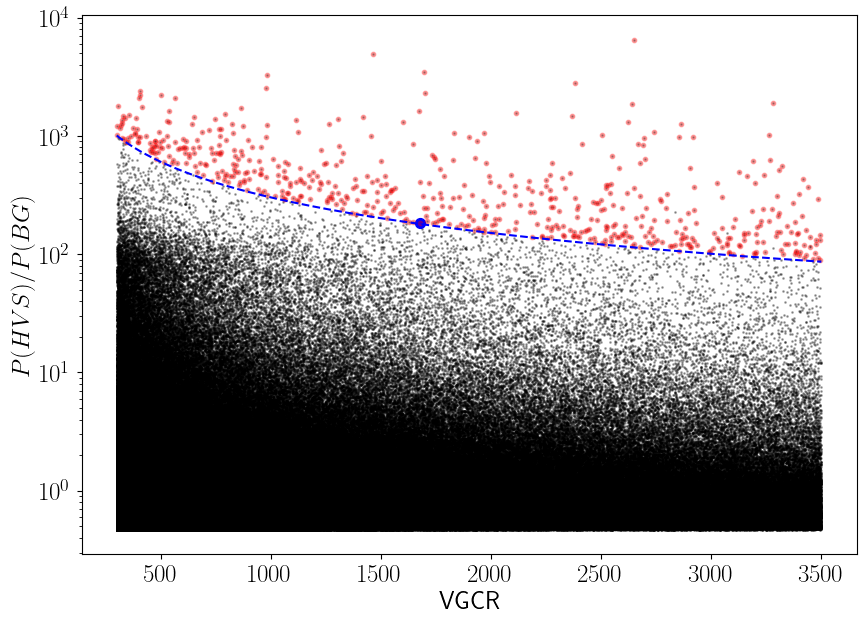

In [117]:
# VGCR vs likelihood ratio
fig, ax = plt.subplots()
ax.scatter(candidates['VGCR'], candidates['p_hvs_over_bg'], c='black', s=1, alpha=0.3)

# plot the S5HVS1
ax.scatter(s5hvs1['VGCR'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1)

# show limit on likelihood ratio
#ax.axhline(100, color='red', linestyle='--')
threshold_scale_factor = 3e5 # 2.6 to include down to S5HVS1

# selection of HVS candidates
candidates_HL = candidates_blue[candidates_blue['p_hvs_over_bg'] > f_convex_down(candidates_blue['VGCR'], a=threshold_scale_factor, c=0, k=0.999)]
print(s5hvs1['p_hvs_over_bg'] > f_convex_down(s5hvs1['VGCR'], a=threshold_scale_factor, c=0, k=0.999))
# remove the MW disk
#candidates_HL = candidates_blue[(candidates_HL['b'] > 30) | (candidates_HL['b'] < -30)]
print(len(candidates_HL))

# selection
ax.scatter(candidates_HL['VGCR'], candidates_HL['p_hvs_over_bg'], c='red', s=10, alpha=0.3)

# show a linearly decreasing line in logspace
x = np.linspace(300, 3500, 1000)
y =  f_convex_down(x, a=threshold_scale_factor, c=0, k=0.999)# + 200
ax.plot(x, y, color='blue', linestyle='--')

ax.set_yscale('log')
ax.set_xlabel('VGCR')
ax.set_ylabel('$P(HVS)/P(BG)$')
plt.savefig(plot_dir + 'VGCR_vs_likelihood_ratio_BLUE.png', dpi=300)
plt.show()
candidates_HL_blue = candidates_HL

158


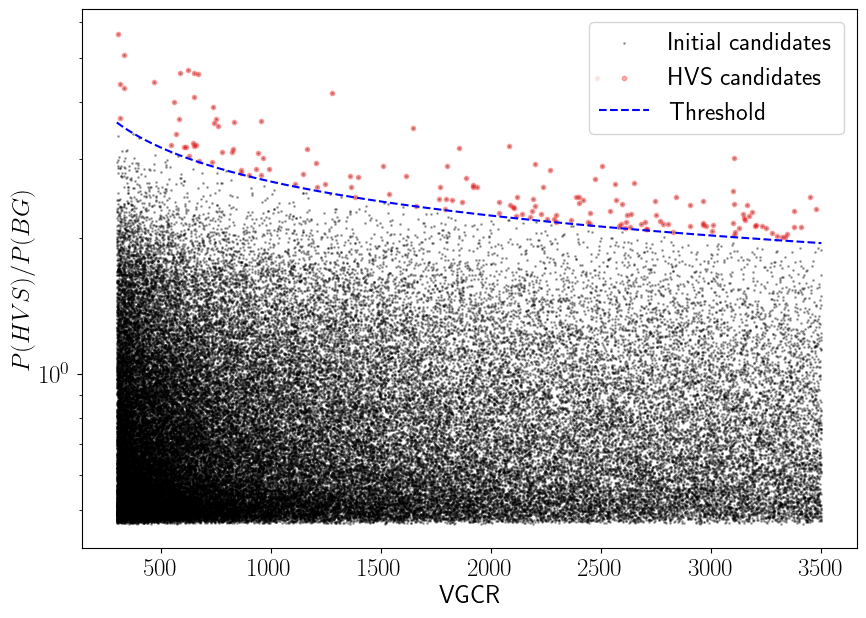

In [118]:
# VGCR vs likelihood ratio
fig, ax = plt.subplots()
ax.scatter(candidates_red['VGCR'], candidates_red['p_hvs_over_bg'], c='black', s=1, alpha=0.3, label='Initial candidates')

# plot the S5HVS1
#ax.scatter(s5hvs1['VGCR'], s5hvs1['p_hvs_over_bg'], c='blue', s=50, alpha=1, label='S5HVS1')

# show limit on likelihood ratio
#ax.axhline(100, color='red', linestyle='--')
threshold_scale_factor = 1.5e1 # 2.6 to include down to S5HVS1

k_sel = 0.25

# selection of HVS candidates
candidates_HL = candidates_red[candidates_red['p_hvs_over_bg'] > f_convex_down(candidates_red['VGCR'], a=threshold_scale_factor, c=0, k=k_sel)]
# remove the MW disk
#candidates_HL = candidates_blue[(candidates_HL['b'] > 30) | (candidates_HL['b'] < -30)]
print(len(candidates_HL))

# selection
ax.scatter(candidates_HL['VGCR'], candidates_HL['p_hvs_over_bg'], c='red', s=10, alpha=0.3, label='HVS candidates')

# show a linearly decreasing line in logspace
x = np.linspace(300, 3500, 1000)
y =  f_convex_down(x, a=threshold_scale_factor, c=0, k=k_sel)# + 200
ax.plot(x, y, color='blue', linestyle='--', label='Threshold')

ax.set_yscale('log')
ax.set_xlabel('VGCR')
ax.set_ylabel('$P(HVS)/P(BG)$')
plt.legend()
plt.savefig(plot_dir + 'VGCR_vs_likelihood_ratio_RED.png', dpi=300)
plt.show()
candidates_HL_red = candidates_HL

In [119]:
from astropy.table import vstack
# save the catalogs
candidates_HL_red.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_red_disk.fits', overwrite=True)
candidates_HL_blue.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_blue_disk.fits', overwrite=True)

# merge the catalogs
candidates_HL_purple = vstack([candidates_HL_red, candidates_HL_blue])

In [120]:
# crossmatch catalog with LAMOST
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import match_coordinates_sky

# define the skycoord for the candidates
candidates_skycoord = SkyCoord(ra=candidates_HL_purple['ra']*u.deg, dec=candidates_HL_purple['dec']*u.deg)
lamost_lr_skycoord = SkyCoord(ra=lamost_lr['ra'], dec=lamost_lr['dec'])
lamost_mr_skycoord = SkyCoord(ra=lamost_mr['ra'], dec=lamost_mr['dec'])

# crossmatch
idx, d2d, _ = match_coordinates_sky(candidates_skycoord, lamost_lr_skycoord)
idx_mr, d2d_mr, _ = match_coordinates_sky(candidates_skycoord, lamost_mr_skycoord)

# select those that are within 1 arcsec
mask = d2d < 1*u.arcsec
mask_mr = d2d_mr < 1*u.arcsec

# select the LAMOST sources
candidates_lamost_lr = candidates_HL_purple[mask]
candidates_lamost_mr = candidates_HL_purple[mask_mr]

# save the catalogs
candidates_lamost_lr.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_lamost_lr.fits', overwrite=True)
candidates_lamost_mr.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_lamost_mr.fits', overwrite=True)

# remove sources that are in those catalogs from the main purple catalog
candidates_purple = candidates_HL_purple[(~mask)|(~mask_mr)]


In [121]:
# crossmatch with Gaia RV to remove every star with a RV measurement
from astroquery.gaia import Gaia


# crossmatch with Gaia
candidates_skycoord = SkyCoord(ra=candidates_purple['ra']*u.deg, dec=candidates_purple['dec']*u.deg)
query = f"""
SELECT source_id, radial_velocity, ra, dec
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', {candidates_purple['ra'].mean()}, {candidates_purple['dec'].mean()}, 1/3600)
)
"""
job = Gaia.launch_job_async(query)
rv_gaia = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [122]:
candidates_purple.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/candidates_HL_purple_disk.fits', overwrite=True)

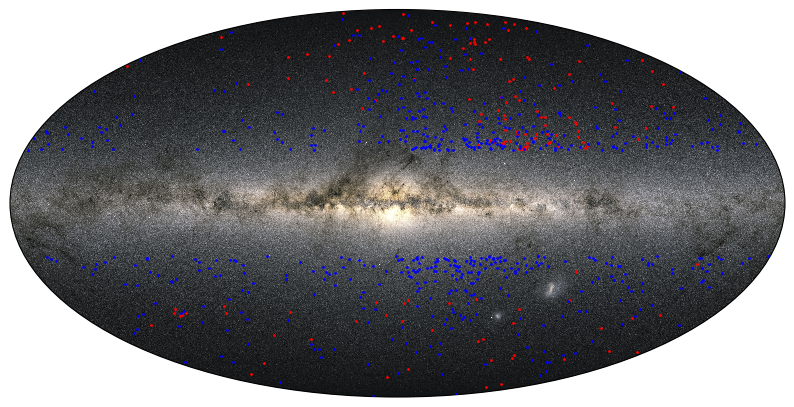

In [123]:
# mollwide plot of sources
m = MWSkyMap(projection='mollweide', figsize=(10, 7))
#m.scatter(candidates_purple['ra']*u.deg, candidates_purple['dec']*u.deg, s=1, c='black', alpha=1)#
m.scatter(candidates_HL_red['ra']*u.deg, candidates_HL_red['dec']*u.deg, s=1, c='red', alpha=1)
m.scatter(candidates_HL_blue['ra']*u.deg, candidates_HL_blue['dec']*u.deg, s=1, c='blue', alpha=1)
plt.savefig(os.path.join('HVS_candidates_mollwide_purple_disk.png'), dpi=300)
plt.show()

In [129]:
# sect sources observable from the south in november, ie., dec < 0 and -60 < ra < 140
candidates_purple_south = candidates_purple[(candidates_purple['dec'] < 0) & (candidates_purple['ra'] > -60) & (candidates_purple['ra'] < 140)]
candidates_HL_blue_south = candidates_HL_blue[(candidates_HL_blue['dec'] < 0) & (candidates_HL_blue['ra'] > -60) & (candidates_HL_blue['ra'] < 140)]
candidates_HL_red_south = candidates_HL_red[(candidates_HL_red['dec'] < 0) & (candidates_HL_red['ra'] > -60) & (candidates_HL_red['ra'] < 140)]

In [130]:
print(len(candidates_purple_south))

114


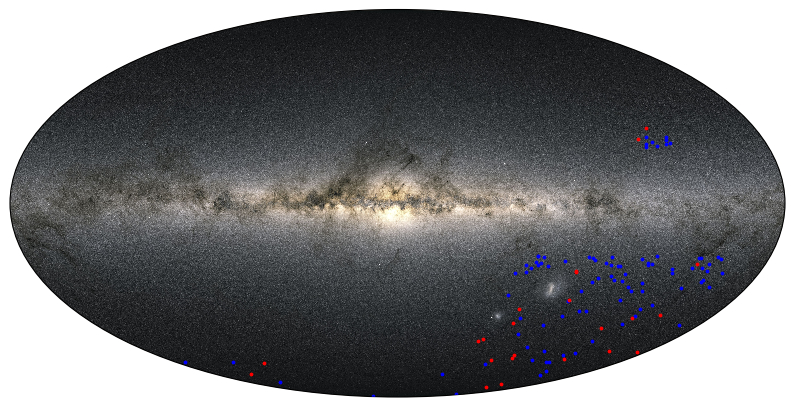

In [132]:
# plot candidates south
m = MWSkyMap(projection='mollweide', figsize=(10, 7))
#m.scatter(candidates_purple_south['ra']*u.deg, candidates_purple_south['dec']*u.deg, s=1, c='black', alpha=1)
m.scatter(candidates_HL_blue_south['ra']*u.deg, candidates_HL_blue_south['dec']*u.deg, s=3, c='blue', alpha=1)
m.scatter(candidates_HL_red_south['ra']*u.deg, candidates_HL_red_south['dec']*u.deg, s=3, c='red', alpha=1)
plt.savefig(os.path.join('HVS_candidates_mollwide_purple_disk_south_nov.png'), dpi=300)
plt.show()


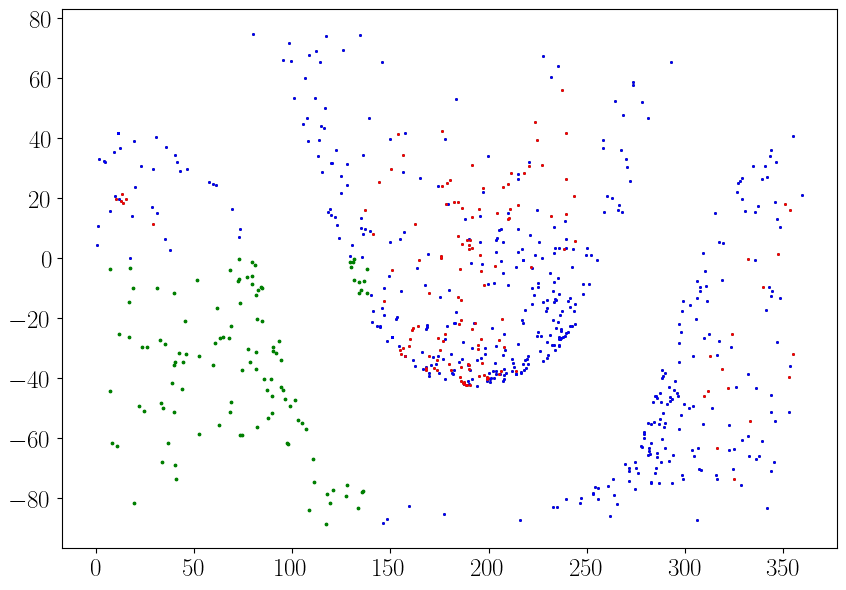

In [140]:
# now a regular mollwide plot showing the ones in the south, the ones in the north and the ones that match november and those that don't
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(candidates_purple['ra']*u.deg, candidates_purple['dec']*u.deg, s=1, c='black', alpha=1)
ax.scatter(candidates_HL_blue['ra']*u.deg, candidates_HL_blue['dec']*u.deg, s=1, c='blue', alpha=1)
ax.scatter(candidates_HL_red['ra']*u.deg, candidates_HL_red['dec']*u.deg, s=1, c='red', alpha=1)
ax.scatter(candidates_purple_south['ra']*u.deg, candidates_purple_south['dec']*u.deg, s=3, c='green', alpha=1)
plt.savefig(os.path.join('HVS_candidates_mollwide_purple_disk_south_nov.png'), dpi=300)
plt.show()

In [133]:
# save the catalogs
candidates_purple_south.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/november/candidates_HL_purple_disk_south_nov.fits', overwrite=True)
candidates_HL_blue_south.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/november/candidates_HL_blue_disk_south_nov.fits', overwrite=True)
candidates_HL_red_south.write('/Users/mncavieres/Documents/2024-2/HVS/Data/candidates/november/candidates_HL_red_disk_south_nov.fits', overwrite=True)

In [134]:
print(len(candidates_HL_blue_south))

91


In [135]:
print(len(candidates_HL_red_south))

23


In [ ]:
# print the lower limit of each bin


# Select observable in south

## RA histogram to select best month



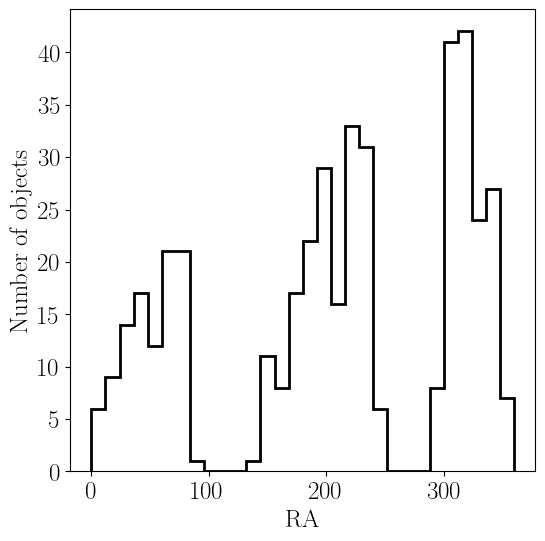

In [65]:
fig, ax = plt.subplots()
ax.hist(candidates_HL_blue['ra'], bins=30, color='black', histtype='step', linewidth=2)
ax.set_xlabel('RA')
ax.set_ylabel('Number of objects')
plt.show()

In [99]:
# observability 
import sys
sys.path.append('/Users/mncavieres/Documents/2024-2/HVS/Notebooks/observation_plan')
import observability_calculation as obs

# import earth location
from astropy.coordinates import EarthLocation

la_silla = EarthLocation.of_site('lasilla')

In [70]:
candidates_HL_blue = obs.check_observability_midnight(candidates_HL_blue, '01-05-2026', '30-04-2027', location=la_silla)

Processing stars: 100%|██████████| 424/424 [01:05<00:00,  6.47it/s]


In [79]:
# change best month from name to number
month_dict = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
              'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
candidates_HL_blue['best_month_n'] = [month_dict[month] for month in candidates_HL_blue['best_month']]

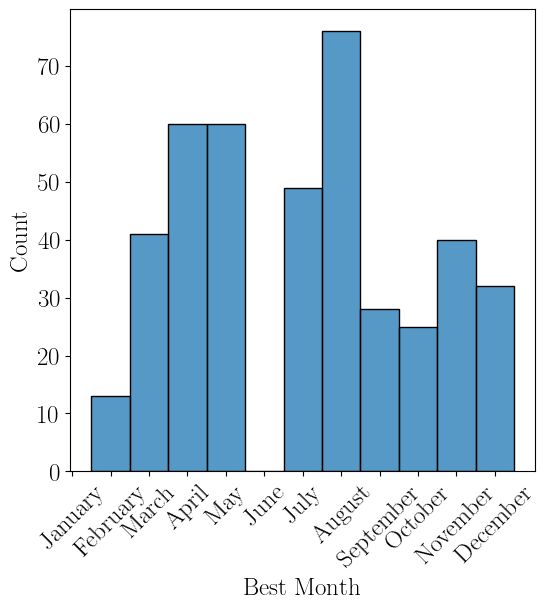

In [98]:
import calendar

fig, ax = plt.subplots()
sns.histplot(data=candidates_HL_blue.to_pandas(), x='best_month_n',
              bins=12, discrete=True, ax=ax)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(calendar.month_name[1:13], rotation=45)
ax.set_xlabel('Best Month')
plt.show()

In [70]:
candidates_HL_blue

SOURCE_ID,l,b,Name,ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,astrometric_params_solved,astrometric_excess_noise,astrometric_excess_noise_sig,ruwe,pseudocolour,nu_eff_used_in_astrometry,ecl_lat,phot_g_mean_mag,phot_g_mean_flux,phot_bp_mean_mag,phot_bp_mean_flux,phot_rp_mean_mag,phot_rp_mean_flux,phot_bp_rp_excess_factor,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,phot_g_mean_flux_error,phot_bp_mean_flux_error,phot_rp_mean_flux_error,bp_rp,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,A_G,A_bp,A_rp,G_corr,phot_bp_mean_mag_corr,phot_rp_mean_mag_corr,bp_rp_corr,implied_M_g,implied_M_g_corr,implied_M_g_corr_error,bp_rp_error,p_hvs,p_background,p_data,p_hvs_over_bg,healpix_pixel,3d_velocity,x,y,z,vx,vy,vz
int64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64
6401710125478435200,329.67749364734846,-39.35867682828743,HVS6401710125478435200,318.5083473169339,0.011116884,-64.64648007078284,0.013794178,0.2342111605042601,0.018169573,16.2311843801476,0.01410217,-16.99396037153359,0.017325148,31,0.13926433,15.716739,1.120806,--,1.7598435,-45.74722923395538,13.953102,49397.60736112456,13.9426985,36169.09237172026,13.980985,20265.83254653837,1.1424627,3729.3252,3435.967,4054.6885,3800.7253,3540.158,4127.5566,20.315727,25.839138,11.593936,-0.03828621,0.2239511620771341,0.0003909458347022,357.62481180889404,36.42561005770136,4465.259258871701,7.794889260365403,0.0953764,0.123558104,0.07235204,13.857726,13.81914,13.908632,-0.089491844,0.7038687134667008,0.6084923113270371,0.7076560926923605,0.0009937037414825,0.9992772770985698,0.0007227229014301,1.775400052162306e-71,655.6405839312572,2842,357.62481180889404,-5149.0448162799075,-1743.0501227760387,-2818.568302274628,-300.7228292008101,-101.80042766431713,-164.61457695529091
6274621081115920768,325.363037560966,35.84264980599124,HVS6274621081115920768,212.58202195900964,0.042250462,-23.56926095593185,0.03272576,0.2525671710819215,0.041408878,-24.80154151043136,0.052813664,-1.8783549510651436,0.039131247,95,0.24595632,18.484774,1.1875886,1.6933398,--,-9.818403692652671,14.348168,34330.43005478608,14.3376665,25139.122452082414,14.33863,14578.283296528318,1.1569154,3417.8748,2956.592,3957.3394,4498.313,4018.3457,5274.9087,31.950949,27.99146,11.897133,-0.00096321106,0.2316201772206576,0.0009757635787977,368.1776284916601,34.15449004986285,4317.413154585966,18.18828809052273,0.21296003,0.2758852,0.16155036,14.135208,14.061781,14.177079,-0.11529827,1.1720503209647717,0.9590902863559309,1.1811790294599973,0.0014988643432223,0.999124672491278,0.0008753275087221,4.841352351973142e-05,542.0133976309355,2786,368.1776288303833,-5235.9698435672635,-1989.2131990922853,2541.5282407568084,-313.4281503710598,-119.06396806437944,152.1227544942053
3476620793110135296,293.8339797282353,36.56114264457077,HVS3476620793110135296,184.75406414358585,0.022370426,-25.7371905181474,0.016455255,0.2081749741502139,0.027776726,-15.17253847284572,0.030426763,-0.163137893043633,0.02234141,31,0.114054844,5.1350174,1.0925725,--,1.762872,-21.63633424855336,14.5232935,29216.56588815641,14.51038,21441.992106514845,14.540023,12110.134289624446,1.1483939,4109.1885,3725.595,4571.304,4125.0083,3800.6406,4761.834,14.925461,16.156313,14.841083,-0.029643059,0.1844800832616297,0.0007030050231252,300.71214627363645,274.0698225150871,5420.639357484459,20.65662932002196,0.26373354,0.34166119,0.20006686,14.25956,14.168718,14.339956,-0.17123795,0.8530409249849562,0.589